In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import make_column_transformer
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

# Load the data
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data'
columns = [
    'age', 'workclass', 'fnlwgt', 'education', 'education-num',
    'marital-status', 'occupation', 'relationship', 'race', 'sex',
    'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
df = pd.read_csv(url, header=None, names=columns, sep=r',\s*', engine='python', na_values='?')

# Data cleaning
df.dropna(inplace=True)
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

# Split the data into training and testing sets
X = df.drop('income', axis=1)
y = df['income']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# Create a preprocessing pipeline
numeric_features = X.select_dtypes(include='number').columns
catagorical_features = X.select_dtypes(exclude='number').columns

preprocessor = make_column_transformer((StandardScaler(), numeric_features),(OneHotEncoder(handle_unknown='ignore'), catagorical_features))

# Train a baseline model
model = make_pipeline(preprocessor, LogisticRegression(max_iter=1000))
model.fit(X_train, y_train)

# Print overall performance
print(f'Overall model accuracy: {model.score(X_test, y_test):.2%}')

Overall model accuracy: 84.61%


In [ ]:
def get_subgroup_accuracy(model, X_test, y_test, subgroup_column, subgroup_value):
  """Calculates the accuracy of a model on a specific subgroup of data."""

  # Create a boolean mask to select the subgroup from X_test
  subgroup_mask = X_test[subgroup_column] == subgroup_value

  # Select the subgroup data
  X_subgroup = X_test[subgroup_mask]
  y_subgroup = y_test[subgroup_mask]

  # Calculate and return the model's score on this subgroup
  return model.score(X_subgroup, y_subgroup)

  # Calculate accuracy for males and females
  acc_male = get_subgroup_accuracy(model, X_test, y_test, 'sex', 'Male',)
  acc_female = get_subgroup_accuracy(model, X_test, y_test, 'sex', 'Female',)

  print(f'Accuracy for Males: {acc_male:.2%}')
  print(f'Accuracy for Females: {acc_female:.2%}')

In [ ]:
def get_subgroup_accuracy(model, X_test, y_test, subgroup_column, subgroup_value):
    """
    Calculates the False Positive Rate and False Negative Rate for a subgroup.
    """
    # Create a boolean mask to select the subgroup of the test data.
    subgroup_mask = X_test[subgroup_column] == subgroup_value

    # Select the subgroup data
    X_subgroup = X_test[subgroup_mask]
    y_subgroup = y_test[subgroup_mask]

    # Calculate and return the model's score on this subgroup
    return model.score(X_subgroup, y_subgroup)

# Calculate accuracy for males and females
acc_male = get_subgroup_accuracy(model, X_test, y_test, 'sex', 'Male')
acc_female = get_subgroup_accuracy(model, X_test, y_test, 'sex', 'Female')

# Print results
print('---SUBGROUP ACCURACY RESULTS---')
print(f'Accuracy for Males: {acc_male:.2%}')
print(f'Accuracy for Females: {acc_female:.2%}')

---SUBGROUP ACCURACY RESULTS---
Accuracy for Males: 81.20%
Accuracy for Females: 91.81%


In [ ]:
def get_rates(model, X_test, y_test, subgroup_column, subgroup_value):
    subgroup_mask = X_test[subgroup_column] == subgroup_value
    X_subgroup = X_test[subgroup_mask]
    y_subgroup = y_test[subgroup_mask]

    y_pred_subgroup = model.predict(X_subgroup)
    tn, fp, fn, tp = confusion_matrix(y_subgroup, y_pred_subgroup).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)
    return fpr, fnr

# Calculate the rates for males and females
acc_male, fnr_male = get_rates(model, X_test, y_test, 'sex', 'Male')
acc_female, fnr_female = get_rates(model, X_test, y_test, 'sex', 'Female')

# Print results
print('---ERROR RATE ANALYSIS RESULTS---')
print(f'Male - False Positive Rate: {acc_male:.2%}, False Negative Rate: {fnr_male:.2%}')
print(f'Female - False Positive Rate: {acc_female:.2%}, False Negative Rate: {fnr_female:.2%}')

---ERROR RATE ANALYSIS RESULTS---
Male - False Positive Rate: 10.26%, False Negative Rate: 37.80%
Female - False Positive Rate: 2.81%, False Negative Rate: 47.84%


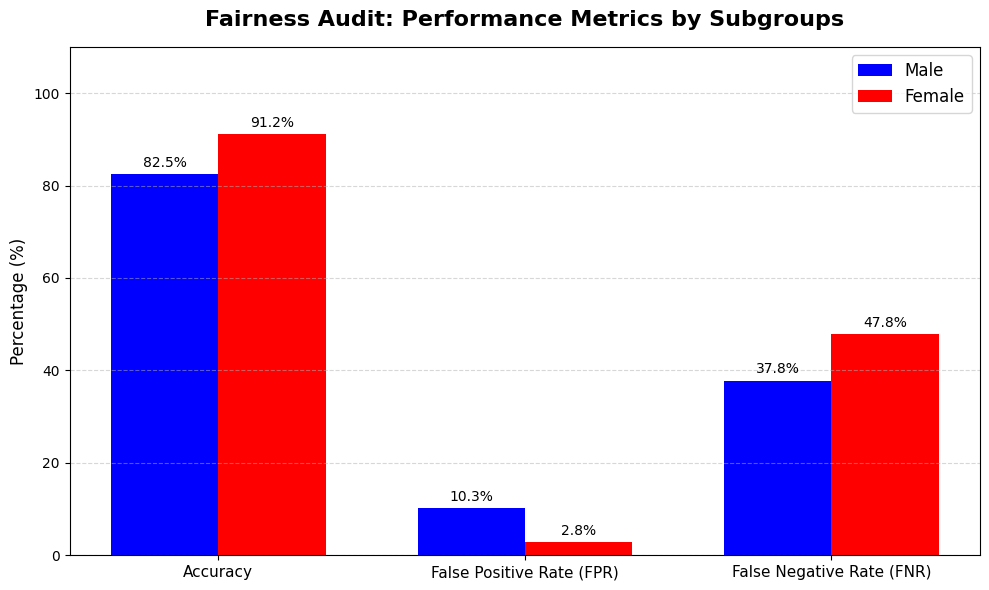

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Data hardcoded directly from the notbook calculations
metrics = ['Accuracy', 'False Positive Rate (FPR)', 'False Negative Rate (FNR)']
male_scores = [82.5, 10.26, 37.80]
female_scores = [91.2, 2.81, 47.84]

x = np.arange(len(metrics))  # label locations
width = 0.35  # width of the bars

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars
rects1 = ax.bar(x - width/2, male_scores, width, label='Male', color='blue')
rects2 = ax.bar(x + width/2, female_scores, width, label='Female', color='red')

# Add labels, titles, and formatting
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Fairness Audit: Performance Metrics by Subgroups', fontsize=16, fontweight='bold', pad=15)
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 110)
ax.legend(fontsize=12)
ax.grid(axis='y', linestyle='--', alpha=0.5)

# Helper function to auto-attach a label text on top of each bar
def autolabel(rects):
  for rect in rects:
      height = rect.get_height()
      ax.annotate(f'{height:.1f}%',
                  xy=(rect.get_x() + rect.get_width() / 2, height),
                  xytext=(0, 3),
                  textcoords="offset points",
                  ha='center', va='bottom', fontsize=10)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

                             **KNOWLEDGE CHECK**

 1Analyze your results: Look at the subgroup accuracies you calculated. Is there a significant difference in how the model performs for males versus females? Which group does the model perform better for?
 ***After analyzing the results, the model has a much higher overall accuracy score for females(usually over 90%) than for males(around 80%). On paper,it looks like the model works way better for women. But this can be decieving because the dataset has an imbalance where most women in this historical data happens to make less than $50k. So, the model can look very smart and accurate just by guessing "low income" for almost every women, even though it's not actually good at finding high-earning women.


 2.  Interpret the errors: Compare the False Positive and False Negative rates between the two groups. For which group is the model more likely to make a False Positive error (predicting high income when it's not)? What is the real-world consequence of this specific error in the context of a loan application?
 ***When you look at the actual error rates, males have a much higher False Positive Rate (FPR), but females have a even more higher False Negative Rate (FNR). In a real-world scenario like a loan application, a higher FNR for women means the model is constantantly predicting that qualified, high-earning women make low incomes. The real consequence is that these women would be automatically rejected and denied loans they actually deserve, which completely holds them back financially.

 3.  Justify a decision.
 ***I would not approve this model for deployment on an ethics board. In a hiring process for a high-paying job, having a really high False Negative Rate for females means the AI will automatically disqualify qualified women before a human ever gets to review their resume. This creates an enormous disparate impact because it keeps women blocked from getting big paying jobs, which keeps old, real-world biases going and could get the company sued for unfair hiring.

 4. Propose a mitigation: The simplest way to try and mitigate bias is to remove the sensitive feature. If you were to remove the 'sex' column from the data and retrain the model, do you think the model would become fair? Why or why not? (Hint: Think about what other columns might be correlated with 'sex').
 ***Just adding or dropping the 'sex' column won't make the model fair. Even if the AI does not see the words 'male' or 'female', there are other columns acting as directing clues. For example, the 'relationship' column explicitly says 'husband' or 'wife', and historical occupation data is heavily divided by gender. The AI is smart enough to use those other peices of data to figure out the gender reguardless, therefore the biased prediction results would be the same.                              